## PROFITABILITY and DISCOUNT IMPACT ANALYSIS (REGION-WISE)

### Business Performance Review using the Superstore Dataset

## Project Overview

This project analyzes retail sales data from the Sample Superstore dataset to evaluate overall business profitability and identify the key factors affecting profit margins across different regions and product categories.

The analysis focuses on understanding whether discounting strategies are negatively impacting profitability. By exploring sales trends, profit distribution, and discount behavior across regions and product categories, the project aims to uncover potential inefficiencies in pricing strategies.

The ultimate goal of this analysis is to identify the root cause of profit losses and provide data-driven business recommendations to improve profitability.

## Business Problem

Despite strong sales performance, the company experiences inconsistent profitability across different regions and product categories.

Management wants to understand:

• Which regions generate the most revenue and profit  
• Which product categories perform well or poorly  
• Whether discounting strategies are negatively affecting profitability  
• What specific factors are contributing to profit losses

By answering these questions, the company can optimize pricing strategies and improve overall profitability.

## Dataset Overview

The dataset used in this project is the **Sample Superstore dataset**, which contains retail transaction data for a fictional superstore.

Key fields included in the dataset:

• Order Date – Date when the order was placed  
• Ship Date – Date when the order was shipped  
• Region – Geographic region where the order was placed  
• Category – High-level product category  
• Sub-Category – Detailed product classification  
• Sales – Total revenue generated from the order  
• Profit – Profit or loss generated from the order  
• Discount – Discount applied to the product  
• Quantity – Number of items sold

This dataset enables analysis of sales performance, profitability trends, and pricing strategies across different regions and product categories.

## Data Preparation

Before performing analysis, the dataset was cleaned and prepared to ensure data quality and consistency.

The following preprocessing steps were performed:

- Converted date columns to datetime format for accurate time-based analysis  
- Checked the dataset for missing values  
- Verified the dataset for duplicate records  
- Created additional calculated fields required for analysis (such as shipping duration)

These steps ensured that the dataset was reliable and ready for exploratory data analysis.


## Tools Used
- Python
- Pandas
- Matplotlib / Seaborn
- Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
df = pd.read_csv("D:\DATA ANALYSIS PREP\PROJECT-1\Sample - Superstore-2.csv",encoding="latin-1")
df


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,Hon Deluxe Fabric Upholstered Stacking Chairs,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,It's Hot Message Books with Stickers,29.6000,4,0.00,13.3200


In [30]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

In [4]:
df.isnull().sum()

Unnamed: 0       0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [7]:
#Profit Margin

df['Profit_Margin'] =(df['Profit'] / df['Sales']).fillna(0)
df

,Unnamed: 0,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Profit_Margin
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,0.1600
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,0.3000
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,0.4700
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,-0.4000
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,0.1125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,0.1625
9990,9991,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,0.1700
9991,9992,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,0.0750
9992,9993,CA-2017-121258,2/26/2017,03-03-2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,0.4500


## Company Performance Overview

Before analyzing specific segments, it is important to understand the company's overall performance.

The following key metrics provide a high-level overview of the business:
- Total Revenue
- Total Profit
- Total Orders
- Average Order Value (AOV)
- Overall Profit Margin

In [8]:
# Total Revenue

Total_Revenue = df['Sales'].sum()
print(Total_Revenue)

2297200.8603000003


In [9]:
# Total Profit

Total_Profit = df['Profit'].sum()
print(Total_Profit)

286397.0217


In [10]:
# Total Orders

Total_Orders = df['Order ID'].nunique()
print(Total_Orders)

5009


In [12]:
# Average Order Value

AOV = Total_Revenue / Total_Orders    
print(f'AOV:${AOV:,.2f}')              

AOV:$458.61


In [13]:
# Overall Profit Margin

Profit_Margin = df['Profit'].sum() / df['Sales'].sum()   
print(f'Profit_Margin:{Profit_Margin: .2%}')


Profit_Margin: 12.47%


The company demonstrates a **healthy baseline level of profitability**. However, further analysis is required to determine whether certain regions or product categories are negatively impacting overall margins.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was conducted to understand the distribution of sales, profits, and discounts across different regions and product categories.

The goal of this step was to identify patterns, anomalies, and potential areas contributing to profit losses.

## Regional Performance Analysis

To understand geographical performance differences, profitability and sales were analyzed across all regions.

This helps identify whether specific regions are underperforming or generating lower profit margins compared to others.

In [14]:
df.groupby('Region')['Sales'].agg('sum').sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [15]:
df.groupby('Region')['Profit'].agg('sum').sort_values(ascending=True)

Region
Central     39706.3625
South       46749.4303
East        91522.7800
West       108418.4489
Name: Profit, dtype: float64

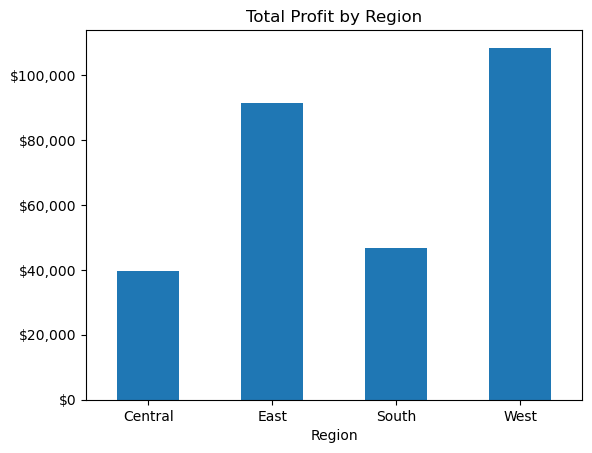

In [16]:
ax=df.groupby('Region')['Profit'].sum().plot(kind='bar', title='Total Profit by Region')
plt.xticks(rotation=0)
fmt = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmt) 
ax.yaxis.set_major_formatter(tick)

### Insight

The West region generates the highest profit, indicating strong overall performance in this market. The East region also performs well in terms of profitability.

However, the Central region shows significantly weaker profit performance compared to its sales contribution. This suggests that factors such as discounting, pricing strategy, or operational costs may be negatively impacting profitability in this region.

In [17]:
# PROFIT MARGIN BY REGION

region_stats = df.groupby('Region')[['Profit','Sales']].sum()

Profit_Margin_Reg = region_stats['Profit'] / region_stats['Sales']
print(Profit_Margin_Reg*100)

Region
Central     7.921629
East       13.483399
South      11.934342
West       14.944831
dtype: float64


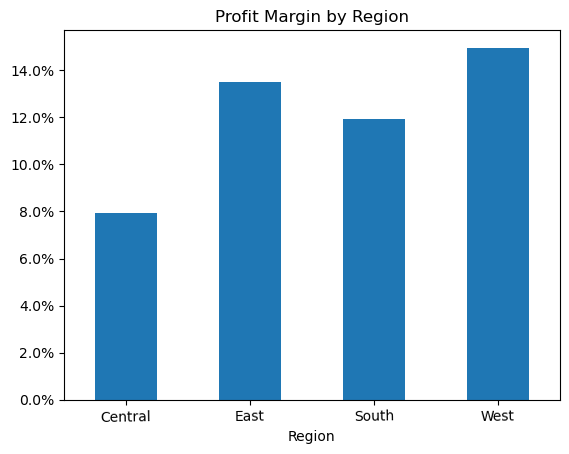

In [18]:
ax=Profit_Margin_Reg.plot(kind='bar', title='Profit Margin by Region')
plt.xticks(rotation=1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

### Insight

The Central region shows noticeably lower profitability compared to the other regions, suggesting potential structural issues such as excessive discounting, higher costs, or weaker pricing strategies.

## Product Category Performance

Next, the profitability of different product categories was evaluated to determine whether specific product groups contribute more heavily to profit erosion.

In [19]:
df.groupby('Category')['Sales'].agg('sum').sort_values(ascending=True)

Category
Office Supplies    719047.0320
Furniture          741999.7953
Technology         836154.0330
Name: Sales, dtype: float64

In [20]:
df.groupby('Category')['Profit'].agg('sum').sort_values(ascending=True)

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [21]:
# PROFIT MARGIN BY CATEGORY

category_stats = df.groupby('Category')[['Profit','Sales']].sum()
#df['Profit_Margin'] =(df['Profit'] / df['Sales']).fillna(0)
Profit_Margin_Cat = category_stats['Profit'] / category_stats['Sales']
print(Profit_Margin_Cat*100)

Category
Furniture           2.486695
Office Supplies    17.035158
Technology         17.395712
dtype: float64


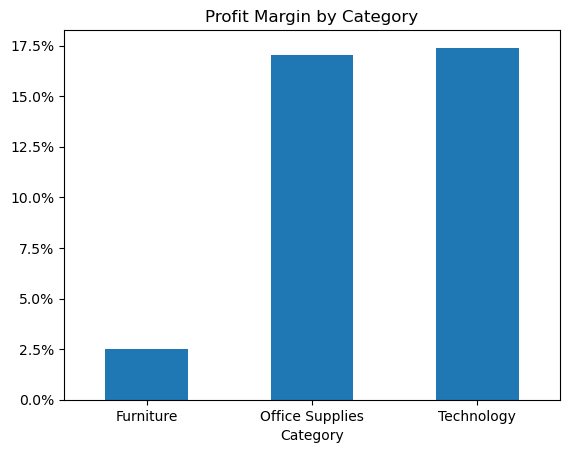

In [22]:
ax=Profit_Margin_Cat.plot(kind='bar', title='Profit Margin by Category')
plt.xticks(rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.show()

### Insight

**Furniture** displays **significantly lower profit margins** compared to Technology and Office Supplies, indicating that products within this category may **require deeper investigation.**

## Region and Category Breakdown

To identify the root cause of the performance issue, profit margins were further segmented by both region and product category.

In [24]:
# Profit Margin by Region and Category

ReCat_stats = df.groupby(['Category','Region'])[['Profit','Sales']].sum()

Profit_Mar_ReCat = ReCat_stats['Profit'] / ReCat_stats['Sales']
print(Profit_Mar_ReCat*100)

Category         Region 
Furniture        Central    -1.752808
                 East        1.462455
                 South       5.772619
                 West        4.554382
Office Supplies  Central     5.316512
                 East       19.956873
                 South      15.906235
                 West       23.821180
Technology       Central    19.773595
                 East       17.911961
                 South      13.437908
                 West       17.581383
dtype: float64


The analysis reveals that Furniture in the **Central region** experiences **particularly low profit margins**, making it the **most likely contributor** to overall profitability decline.

## Root Cause Investigation

After identifying that **Furniture in the Central region** has the lowest profitability, further analysis was performed to determine the underlying cause.

Two potential factors were investigated:

• Shipping duration  
• Discount levels

In [31]:
#If high shipping cost correlates with Central Furniture losses

df['Shipping Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

In [33]:
# Filter for Central Furniture

central_furni = df[(df['Region']=='Central') & (df['Category']=='Furniture')]
              
correl = central_furni['Shipping Duration'].corr(central_furni['Profit'])
print(f'Correlation between Shipping and Profit:{correl :.4f}')

Correlation between Shipping and Profit:-0.0129


The **correlation** between **shipping duration and profit is extremely weak**, suggesting that **shipping delays** are **not a major factor contributing to profit losses.**

### Discount Test

In [34]:
# Checking if deeper discounts are directly destroying the Profit

disc_corr = central_furni['Discount'].corr(central_furni['Profit'])
print(f'Correlation between Discount and Profit :{disc_corr:.4f}')

Correlation between Discount and Profit :-0.4812


In [35]:
# Worst offender Sub-Category

subcat_corr = central_furni.groupby('Sub-Category').apply(lambda x: x['Discount'].corr(x['Profit']),include_groups=False)
print(subcat_corr)

Sub-Category
Bookcases     -0.591881
Chairs        -0.653511
Furnishings   -0.429603
Tables        -0.795971
dtype: float64


A **moderate negative correlation** was **observed between discount levels and profit**. This **indicates** that **higher discounts are associated with declining profitability**.

## Discount Impact Analysis

One potential factor influencing low profitability is aggressive discounting.

To investigate this, the relationship between discount levels and profit was analyzed.

In [23]:
# Average discount by Region × Category

avg_dis = df.groupby(['Category','Region'])[['Discount']].mean()
print(avg_dis*100)

                          Discount
Category        Region            
Furniture       Central  29.738046
                East     15.407654
                South    12.153614
                West     13.140028
Office Supplies Central  25.274262
                East     14.293224
                South    16.743719
                West      9.335793
Technology      Central  13.309524
                East     14.336449
                South    10.784983
                West     13.388982


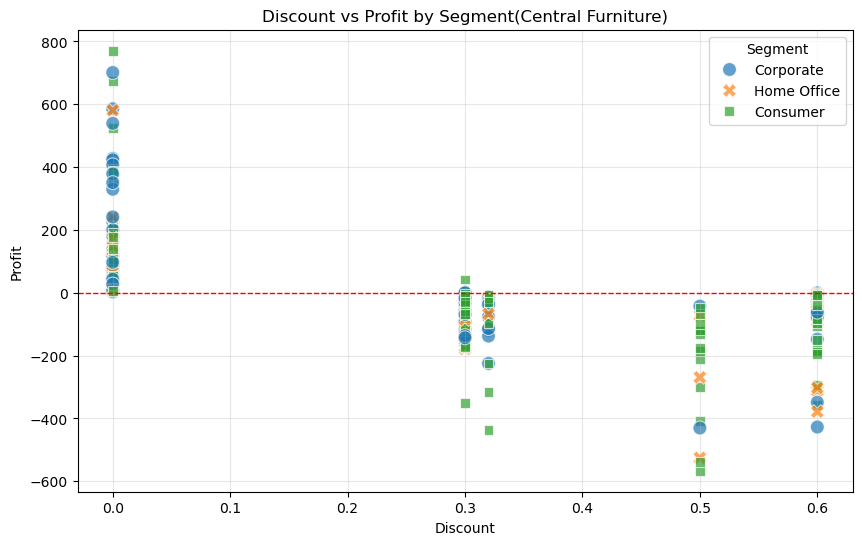

In [27]:
focus_data = df[(df['Region']=='Central') & (df['Category']=='Furniture')]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data = focus_data,
    x = 'Discount',
    y = 'Profit',
    hue = 'Segment',
    style = 'Segment',
    s = 100,      # Dot size
    alpha = 0.7)  #Transparency to see overlapping dots

plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.title('Discount vs Profit by Segment(Central Furniture)')
plt.grid(True, alpha=0.3)
plt.show()

### Insight

The analysis **reveals a clear negative relationship between discount levels and profit**. **Higher discounts** are frequently **associated with lower or even negative profit values**.

This suggests that excessive discounting may be significantly contributing to profit losses in certain segments.

## Sub-Category Analysis

To further pinpoint the source of profit loss, individual sub-categories were analyzed to determine which products are most affected by discount-driven losses.

In [25]:
# Sub-category inside Furniture causing losses

furni_df = df[df['Category'] == 'Furniture']

furni_losses = furni_df.groupby('Sub-Category')['Profit'].sum().sort_values()
print(furni_losses)

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Furnishings    13059.1436
Chairs         26590.1663
Name: Profit, dtype: float64


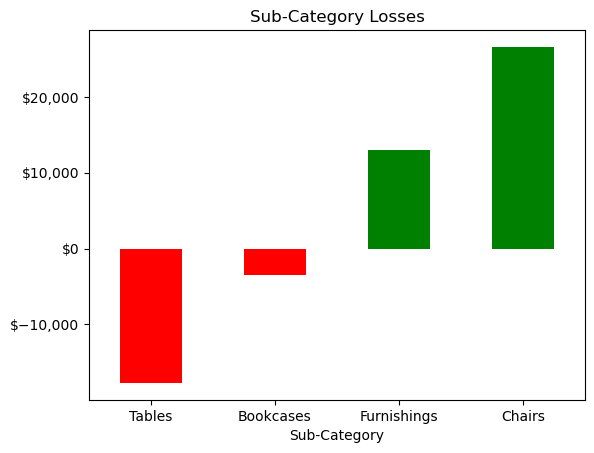

In [26]:
colors = ['red', 'red', 'green', 'green']

ax=furni_losses.plot(kind='bar',color=colors,title='Sub-Category Losses')
plt.xticks(rotation=0)
fmt = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmt) 
ax.yaxis.set_major_formatter(tick)


### Insight

Certain sub-categories such as **Tables and Bookcases generate disproportionately high losses** compared to other products, **indicating** that these items **may be heavily discounted or priced inefficiently**.

## Business Recommendations

Based on the analysis conducted on the Superstore dataset, several key insights were identified that explain the losses in the **Central region's Furniture category**.

### 1. Reduce Deep Discounting on Tables
The analysis revealed a **strong negative correlation (-0.796)** between **discounts and profit** for the *Tables* sub-category in the Central region.  
This suggests that higher discounts on Tables are significantly reducing profitability.

**Recommendation:**  
Implement stricter discount policies or limit excessive discounting on Tables in the Central region.

---

### 2. Review Furniture Pricing Strategy
Furniture products appear to be **highly sensitive to discount levels**, meaning large discounts do not necessarily generate profitable sales.

**Recommendation:**  
Re-evaluate the base pricing and discount strategy for furniture items to maintain healthier profit margins.

---

### 3. Introduce Discount Thresholds
Since increased discounts are strongly associated with declining profits, implementing discount controls could help maintain profitability.

**Recommendation:**  
Introduce a **maximum discount threshold** for furniture products in the Central region to prevent margin erosion.

---

### 4. Investigate Cost Structure for Tables
The sharp decline in profit when discounts increase suggests that **Tables may already have tight margins or higher operational costs**.

**Recommendation:**  
Conduct a deeper cost analysis to determine whether **production costs, logistics, or supplier pricing** are contributing to the issue.

---

## Conclusion

The losses in the **Central region's Furniture category** are primarily driven by **heavy discounting in the Tables sub-category**.  
By optimizing discount policies and reviewing pricing strategies, the company can significantly improve profitability in this segment.

---

## Project Summary

This analysis explored the causes behind losses in the **Central region's Furniture category** using exploratory data analysis and correlation techniques.

The results indicate that **heavy discounting, particularly in the Tables sub-category, is the primary driver of negative profits**.

By implementing stricter discount policies and reviewing pricing strategies, the company could significantly reduce losses and improve profitability in the Central region.

This project demonstrates how data analysis can uncover hidden business problems and support data-driven decision-making.